# Fade the surprise, not the move

Every other notebook here signs the trade off the **price move** in the minute after a release. This
one signs it off the **release against consensus** — how far the printed number landed from what the
street expected — and never looks at the initial move to decide direction at all.

That is a different hypothesis, and the reason to prefer it is mechanical: the move-based signal reads
the price twice and trades on the difference, so bid-ask bounce sets the side. A consensus surprise is
measured in the units of the data, not the units of the market, and cannot bounce.

### The hypothesis, and its fork

A large surprise does one of two things.

**It overshoots** — the market lurches, then gives some back. That is a fade, and it wants a target.

**It reprices** — the number genuinely changed what the curve should be, and the first move was not
enough. That is not a fade, and a fade into it should be stopped out quickly.

The fork is testable. `direction="fade_then_flip"` fades, and if the fade is *stopped* it reverses for
the rest of the window as a **separate trade paying its own round trip** — because a reversal netted
invisibly into the first leg would be free money that no desk gets. §7 reports whether the flip pays.

### Standardising the surprise is where this goes wrong

Releases are in incompatible units — CPI in tenths of a percent, payrolls in thousands — so each is
scored as a z against its own history. Two details decide whether that z means anything.

**The scale must be rolling, not expanding.** An expanding MAD never widens, so June 2020 payrolls
(+10,839k against consensus) scored **z = 178**, and every `|z| >= 2` filter silently became "trade
payrolls in 2020". A 36-observation rolling robust scale with winsorisation at ±5 fixes it.

**The scale must be point-in-time.** A z computed from the full sample tells the 2019 trade what 2026
looked like. `point_in_time_z` uses only what had printed by that date.

---

> **Known before this notebook starts.** The raw-move fade loses on every instrument and horizon
> tested. This notebook asks whether scoring the release against consensus rescues it. §9 answers with
> 40 matched placebo replicas, which is the only section that settles anything.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, copy, itertools, time, warnings
from pathlib import Path

REPO = r"C:\Users\chris\clee\ARBS-eco"
HERE = Path(REPO) / "notebooks" / "backtests" / "econ_release_fade"
sys.path.insert(0, REPO); sys.path.insert(0, str(HERE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "figure.autolayout": True})

import econ_fade_common as G
import econ_fade_config as C
import econ_fade_exits as X
import econ_fade_mdp_exits as MX
import econ_fade_surprise as S
from econ_fade_prewarm import load_events

from RVUtils.StatisticalFinance import (
    ras_bound, romano_wolf, selection_bias_pvalue, shared_sign_flip_null,
)

#: The consensus workbook, COMMITTED next to the notebook. It originally arrived
#: as a session upload, and a notebook that reads from an uploads directory
#: executes once and breaks for everybody else.
XLSX = HERE / "data" / "econ_actual_vs_consensus.xlsx"
assert XLSX.exists(), f"missing {XLSX}"
print("modules loaded;", XLSX.name, f"{XLSX.stat().st_size/1024:.0f} KB")

modules loaded; econ_actual_vs_consensus.xlsx 23 KB


## 1. The configuration

In [2]:
# ---------------------------------------------------------------- the knobs
CONFIG = {
    "name": "surprise",
    "instrument": {"family": "ust", "root": "TY", "rank": 1},
    "releases": ["core cpi mom", "ppi mom", "nfp"],
    "z": {"robust": True,          # median/MAD rather than mean/sd
          "min_obs": 12,           # no z until this many prints have happened
          "min_abs_z": 1.5,        # ONLY trade a surprise at least this large
          "max_abs_z": None,
          "scale_window": 36,      # ROLLING -- see the intro
          "z_cap": 5.0},           # winsorise
    "timing": {"entry_offset_min": 2, "max_staleness_min": 5},
    "signal": {"direction": "fade"},        # fade | momentum | fade_then_flip
    "contracts": 1,
}

BRACKET = dict(tp_bp=1.0, sl_bp=None, trail_bp=None,
               time_stop_min=240, min_hold_min=0, stop_slip_ticks=1.0,
               mode="close")       # "close" is what the ENGINE can see

COST_BP  = 0.2389                  # one ZN tick, one round trip
MIN_TRADES = 30

RULE = X.ExitRule(name="headline", **BRACKET)
print(json.dumps(CONFIG, indent=1, default=str))
print("\nbracket:", RULE)

{
 "name": "surprise",
 "instrument": {
  "family": "ust",
  "root": "TY",
  "rank": 1
 },
 "releases": [
  "core cpi mom",
  "ppi mom",
  "nfp"
 ],
 "z": {
  "robust": true,
  "min_obs": 12,
  "min_abs_z": 1.5,
  "max_abs_z": null,
  "scale_window": 36,
  "z_cap": 5.0
 },
 "timing": {
  "entry_offset_min": 2,
  "max_staleness_min": 5
 },
 "signal": {
  "direction": "fade"
 },
 "contracts": 1
}

bracket: ExitRule(name='headline', tp_bp=1.0, tp_frac=None, sl_bp=None, sl_frac=None, trail_bp=None, time_stop_min=240, min_hold_min=0, stop_slip_ticks=1.0, mode='close')


## 2. The consensus data

`load_surprises` reads the workbook and produces one row per release with `actual`, `forecast` and
their difference. The sheets are mapped to calendar titles with a **hawkish sign** — a hot CPI and a
hot payroll both push yields up, so both carry +1 and a fade of them is the same trade.

In [3]:
sur = S.load_surprises(XLSX)
print(f"{len(sur):,} releases with a consensus, {sur['date'].min().date()} .. {sur['date'].max().date()}")
print()
print(sur.groupby("sheet").agg(n=("surprise", "size"),
                               first=("date", "min"), last=("date", "max"),
                               mean_abs_surprise=("surprise", lambda s: s.abs().mean())).to_string())
sur.head(6)

483 releases with a consensus, 2012-05-04 .. 2026-08-07

                n      first       last  mean_abs_surprise
sheet                                                     
core cpi mom  167 2012-05-15 2026-07-14           0.082635
nfp           170 2012-05-04 2026-08-07         159.423529
ppi mom       146 2014-04-11 2026-07-15           0.238356


,date,actual,expected,sheet,surprise
0,2012-05-15,0.2,0.2,core cpi mom,0.0
1,2012-06-14,0.2,0.2,core cpi mom,0.0
2,2012-07-17,0.2,0.2,core cpi mom,0.0
3,2012-08-15,0.1,0.2,core cpi mom,-0.1
4,2012-09-14,0.1,0.2,core cpi mom,-0.1
5,2012-10-16,0.1,0.2,core cpi mom,-0.1


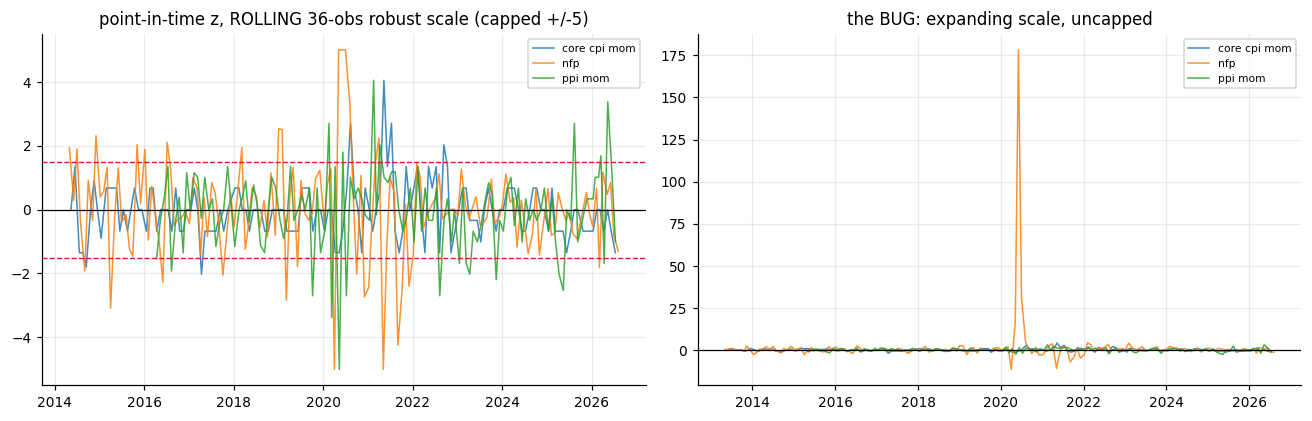

largest |z| under the expanding scale -- this is what broke every |z|>=2 filter:
      date sheet   actual  expected  surprise       z
2020-06-05   nfp   2509.0   -8330.0   10839.0 178.312
2020-07-02   nfp   4800.0    2900.0    1900.0  31.240
2020-05-08   nfp -20500.0  -21500.0    1000.0  16.459

the same releases under the rolling, capped scale:
      date sheet  surprise   z
2020-05-08   nfp    1000.0 5.0
2020-06-05   nfp   10839.0 5.0
2020-07-02   nfp    1900.0 5.0


In [4]:
sz = S.point_in_time_z(sur, robust=True, min_obs=12, scale_window=36, z_cap=5.0)
sz_bad = S.point_in_time_z(sur, robust=True, min_obs=12, scale_window=None, z_cap=None)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.9))
for sheet, g in sz.groupby("sheet"):
    ax[0].plot(g["date"], g["z"], lw=1.0, alpha=0.85, label=sheet)
ax[0].axhline(0, color="k", lw=0.8)
for lv in (1.5, -1.5):
    ax[0].axhline(lv, color="crimson", ls="--", lw=0.9)
ax[0].set_title("point-in-time z, ROLLING 36-obs robust scale (capped +/-5)")
ax[0].legend(fontsize=7)

for sheet, g in sz_bad.groupby("sheet"):
    ax[1].plot(g["date"], g["z"], lw=1.0, alpha=0.85, label=sheet)
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_title("the BUG: expanding scale, uncapped")
ax[1].legend(fontsize=7)
plt.show()

worst = sz_bad.reindex(sz_bad["z"].abs().sort_values(ascending=False).index).head(3)
print("largest |z| under the expanding scale -- this is what broke every |z|>=2 filter:")
print(worst[["date", "sheet", "actual", "expected", "surprise", "z"]].round(3).to_string(index=False))
print()
print("the same releases under the rolling, capped scale:")
m = sz.merge(worst[["date", "sheet"]], on=["date", "sheet"], how="inner")
print(m[["date", "sheet", "surprise", "z"]].round(3).to_string(index=False))

## 3. The book

The gate is the same one the rest of the study uses: an event survives only if a real MDP-convention
price exists at its entry minute. Note what is **not** a reason to drop an event here — "the release
did not move the market". The signal needs no price at all, so a surprise that produced no move is
still a trade, and the book is not quietly conditioned on having moved.

In [5]:
raw = load_events()
G.load_bar_cache(); G.load_dv01()

book = S.build_surprise_book(CONFIG, sur, raw)
print(f"book: {len(book.events):,} tradeable events on {book.instrument.root}")
print("\n--- funnel ---")
for k, v in book.funnel.items():
    print(f"  {k:30s} {v}")

ev = book.events.copy()
ev["ny"] = pd.to_datetime(ev["release_ts"], utc=True).dt.tz_convert("America/New_York")
print("\nby release and year")
print(pd.crosstab(ev["release"], ev["ny"].dt.year).to_string())
ev[["release_ts", "release", "symbol", "surprise", "z", "side", "entry_px"]].head(8)

book: 41 tradeable events on TY

--- funnel ---
  surprise rows                  483
  joined to a release minute     261
  after point-in-time history requirement 261
  dropped: |z| < 1.5             220
  dropped: no print at the entry minute 0
  TRADEABLE                      41

by release and year
ny                          2019  2020  2021  2022  2023  2025  2026
release                                                             
Core CPI m/m                   0     1     2     1     0     0     0
Non-Farm Employment Change     4     7     7     0     0     0     1
PPI m/m                        1     5     0     1     4     3     4


,release_ts,release,symbol,surprise,z,side,entry_px
0,2019-01-04 13:30:00+00:00,Non-Farm Employment Change,TYH19,136.0,2.538215,1.0,122.562500
1,2019-02-01 13:30:00+00:00,Non-Farm Employment Change,TYH19,134.0,2.502716,1.0,122.343750
2,2019-03-08 13:30:00+00:00,Non-Farm Employment Change,TYM19,-160.0,-2.839961,-1.0,122.765625
3,2019-06-07 12:30:00+00:00,Non-Farm Employment Change,TYU19,-105.0,-1.784933,-1.0,127.312500
4,2019-10-08 12:30:00+00:00,PPI m/m,TYZ19,-0.4,-2.697963,-1.0,131.843750
5,2020-02-19 13:30:00+00:00,PPI m/m,TYH20,0.4,2.697963,1.0,131.078125
6,2020-03-12 12:30:00+00:00,PPI m/m,TYM20,-0.5,-3.372454,-1.0,138.828125
7,2020-04-03 12:30:00+00:00,Non-Farm Employment Change,TYM20,-691.0,-5.000000,-1.0,139.156250


## 4. The engine run, and the tie-out

Same discipline as the exits notebook: prime the MDP's own DiskCache from the warmed bars, disarm the
fetcher so a cache miss raises instead of reaching for the network, run the bracket through
`QueryDrivenBacktest`, then **assert** the fast path reproduces it exactly. Every sweep after this
uses the fast path, and this is what makes that legitimate.

In [6]:
mdp = MX.open_ust_mdp(armed=False)
wanted = MX.wanted_minutes(book.events, RULE.time_stop_min)
print(f"{len(wanted):,} (symbol, minute) pairs to prime")
t0 = time.time()
stats = MX.prime_ust_cache(mdp, wanted, show_progress=False)
print(f"primed in {time.time()-t0:.1f}s: {stats}  "
      f"({stats['written'] / max(1, len(wanted)) * 100:.1f}% coverage)")

t0 = time.time()
engine = MX.run_bracket_engine(book, RULE, mdp, cost_bp=COST_BP, show_progress=False)
print(f"engine booked {len(engine):,} trades in {time.time()-t0:.1f}s")

# The engine hands back the portfolio's closed-position log, which knows about
# positions and not about consensus -- so the signal columns this notebook plots
# are joined back on by tag. Doing it here rather than inside a plotting cell
# keeps `engine` the single frame everything downstream reads.
_meta = book.events.set_index("tag")[["z", "surprise", "release", "sheet", "n_prior"]]
engine = engine.join(_meta, on="tag")
assert engine["z"].notna().all(), "a booked trade has no surprise attached"
print(f"joined signal metadata: {list(_meta.columns)}")
engine[["release_ts", "release", "symbol", "surprise", "z", "side", "entry_px",
        "exit_reason", "hold_min", "pnl_bp_gross", "pnl_bp"]].head(10)

9,922 (symbol, minute) pairs to prime


primed in 9.5s: {'written': 9840, 'no_bar': 82, 'no_day': 0}  (99.2% coverage)


engine booked 41 trades in 8.9s
joined signal metadata: ['z', 'surprise', 'release', 'sheet', 'n_prior']


,release_ts,release,symbol,surprise,z,side,entry_px,exit_reason,hold_min,pnl_bp_gross,pnl_bp
0,2019-01-04 13:30:00+00:00,Non-Farm Employment Change,TYH19,136.0,2.538215,1.0,122.562500,time_stop,240.0,-4.300233,-4.539133
1,2019-02-01 13:30:00+00:00,Non-Farm Employment Change,TYH19,134.0,2.502716,1.0,122.343750,target,16.0,1.194509,0.955609
2,2019-03-08 13:30:00+00:00,Non-Farm Employment Change,TYM19,-160.0,-2.839961,-1.0,122.765625,target,54.0,1.202490,0.963590
3,2019-06-07 12:30:00+00:00,Non-Farm Employment Change,TYU19,-105.0,-1.784933,-1.0,127.312500,target,196.0,1.083262,0.844362
4,2019-10-08 12:30:00+00:00,PPI m/m,TYZ19,-0.4,-2.697963,-1.0,131.843750,target,5.0,1.135969,0.897069
5,2020-02-19 13:30:00+00:00,PPI m/m,TYH20,0.4,2.697963,1.0,131.078125,target,135.0,1.098215,0.859315
6,2020-03-12 12:30:00+00:00,PPI m/m,TYM20,-0.5,-3.372454,-1.0,138.828125,target,4.0,1.052820,0.813920
7,2020-04-03 12:30:00+00:00,Non-Farm Employment Change,TYM20,-691.0,-5.000000,-1.0,139.156250,target,17.0,1.263384,1.024484
8,2020-05-08 12:30:00+00:00,Non-Farm Employment Change,TYM20,1000.0,5.000000,1.0,139.171875,target,121.0,1.052820,0.813920
9,2020-05-13 12:30:00+00:00,PPI m/m,TYM20,-0.8,-5.000000,-1.0,139.171875,target,24.0,1.052820,0.813920


In [7]:
fast = MX.run_bracket_fast(book, RULE, cost_bp=COST_BP)
a = engine.set_index("tag").sort_index()
b = fast.set_index("tag").sort_index()
shared = a.index.intersection(b.index)
assert len(shared) == len(a) == len(b), f"engine {len(a)}, fast {len(b)}, shared {len(shared)}"

dpnl = (a.loc[shared, "pnl_bp"] - b.loc[shared, "pnl_bp"]).abs()
same = int((a.loc[shared, "exit_reason"] == b.loc[shared, "exit_reason"]).sum())
print(f"max |pnl_bp diff| : {dpnl.max():.3e}")
print(f"exit reasons agree: {same} / {len(shared)}")
assert dpnl.max() < 1e-9 and same == len(shared), "fast path disagrees with the engine"
print("\nTIE-OUT PASSED")

max |pnl_bp diff| : 8.882e-16
exit reasons agree: 41 / 41

TIE-OUT PASSED


## 5. What the headline configuration is worth

In [8]:
def stats_of(df, label="book"):
    p = df["pnl_bp"].to_numpy(float)
    wins, losses = p[p > 0], p[p <= 0]
    sd = p.std(ddof=1) if len(p) > 1 else 0.0
    return {
        "label": label, "trades": len(p), "hit_rate": float((p > 0).mean()),
        "gross_bp": float(df["pnl_bp_gross"].mean()), "net_bp": float(p.mean()),
        "total_net_bp": float(p.sum()),
        "avg_win": float(wins.mean()) if len(wins) else np.nan,
        "avg_loss": float(losses.mean()) if len(losses) else np.nan,
        "payoff": float(wins.mean() / abs(losses.mean())) if len(wins) and len(losses) else np.nan,
        "sr_per_trade": float(p.mean() / sd) if sd > 0 else 0.0,
        "t_stat": float(p.mean() / (sd / np.sqrt(len(p)))) if sd > 0 else 0.0,
        "avg_hold_min": float(df["hold_min"].mean()),
        "pct_target": float((df.exit_reason == "target").mean()),
        "pct_stop": float(df.exit_reason.isin(["stop", "trail"]).mean()),
        "pct_time": float((df.exit_reason == "time_stop").mean()),
    }

hl = stats_of(engine, "headline (engine)")
print(pd.Series(hl).to_frame("value").to_string())
print()
print(f"a {hl['hit_rate']*100:.1f}% hit rate paying {hl['net_bp']:+.4f} bp/trade net of one tick, "
      f"t = {hl['t_stat']:.2f}, payoff {hl['payoff']:.2f}")
print("a high hit rate with a payoff below 1 is a tight target, not an edge -- both numbers matter")

                          value
label         headline (engine)
trades                       41
hit_rate               0.902439
gross_bp               0.779713
net_bp                 0.540813
total_net_bp          22.173334
avg_win                1.050661
avg_loss              -4.175282
payoff                 0.251638
sr_per_trade           0.330498
t_stat                  2.11622
avg_hold_min          53.853659
pct_target             0.902439
pct_stop                    0.0
pct_time               0.097561

a 90.2% hit rate paying +0.5408 bp/trade net of one tick, t = 2.12, payoff 0.25
a high hit rate with a payoff below 1 is a tight target, not an edge -- both numbers matter


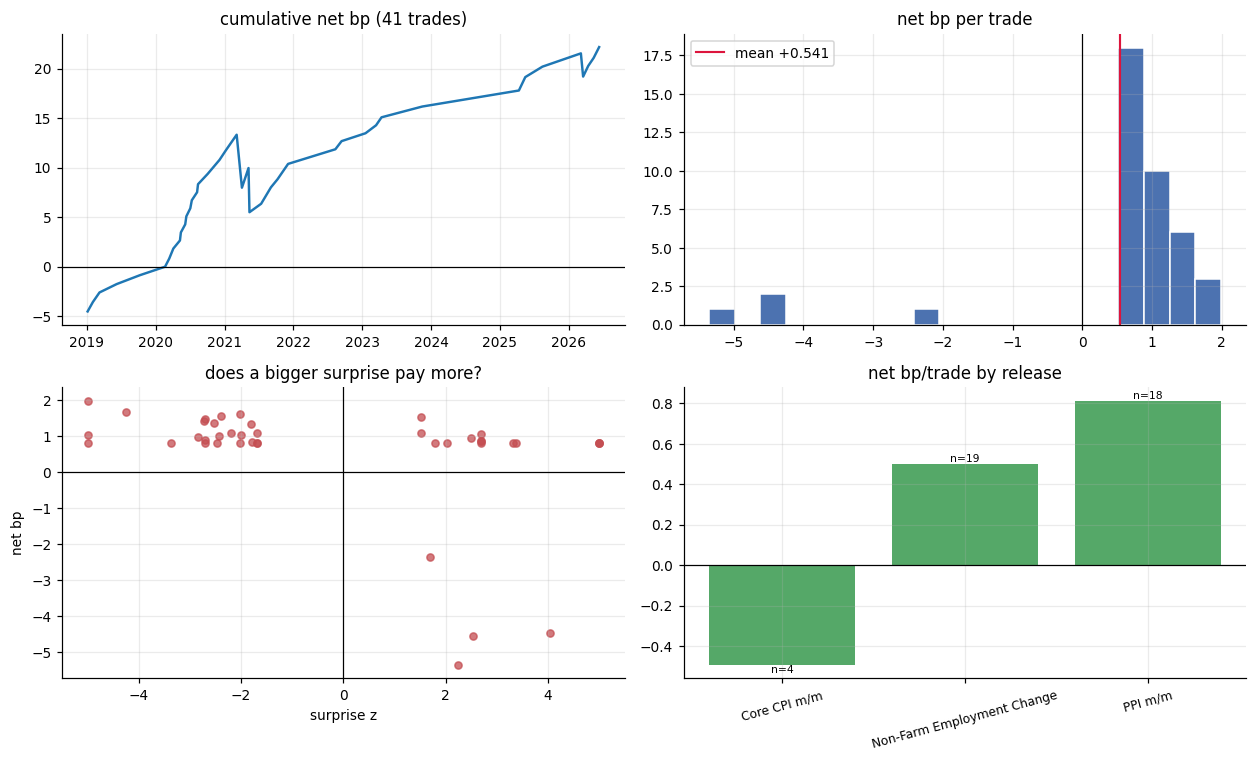

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(11.5, 7))
d = engine.sort_values("release_ts")
ts = pd.to_datetime(d["release_ts"], utc=True).dt.tz_convert("America/New_York")

ax[0, 0].plot(ts, d["pnl_bp"].cumsum(), lw=1.6, color="#1f77b4")
ax[0, 0].axhline(0, color="k", lw=0.8)
ax[0, 0].set_title(f"cumulative net bp ({len(d)} trades)")
ax[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax[0, 1].hist(d["pnl_bp"], bins=20, color="#4c72b0", edgecolor="white")
ax[0, 1].axvline(0, color="k", lw=0.8)
ax[0, 1].axvline(d["pnl_bp"].mean(), color="crimson", lw=1.4, label=f"mean {d['pnl_bp'].mean():+.3f}")
ax[0, 1].legend(); ax[0, 1].set_title("net bp per trade")

ax[1, 0].scatter(d["z"], d["pnl_bp"], s=22, alpha=0.75, color="#c44e52")
ax[1, 0].axhline(0, color="k", lw=0.8); ax[1, 0].axvline(0, color="k", lw=0.8)
ax[1, 0].set_xlabel("surprise z"); ax[1, 0].set_ylabel("net bp")
ax[1, 0].set_title("does a bigger surprise pay more?")

by_rel = d.groupby("release")["pnl_bp"].agg(["size", "mean"])
ax[1, 1].bar(range(len(by_rel)), by_rel["mean"], color="#55a868")
ax[1, 1].set_xticks(range(len(by_rel))); ax[1, 1].set_xticklabels(by_rel.index, rotation=15, fontsize=8)
ax[1, 1].axhline(0, color="k", lw=0.8); ax[1, 1].set_title("net bp/trade by release")
for i, (n, v) in enumerate(zip(by_rel["size"], by_rel["mean"])):
    ax[1, 1].text(i, v, f"n={n}", ha="center", va="bottom" if v >= 0 else "top", fontsize=7)
plt.show()

## 6. Dose response — does a bigger surprise pay more?

The single most informative plot in this notebook. If fading works *because* the market overshoots a
surprise, the edge must grow with the size of the surprise. If the edge is flat in `|z|`, whatever is
being measured is not a surprise effect.

Note that raising the threshold also shrinks the book, so the trade count is printed beside every
point: a rising line built on a collapsing sample is a different claim.

There are three shapes this can come back as, and they mean different things.

- **A ramp** — the edge grows smoothly with `|z|`. That is the clean version of the hypothesis.
- **Flat** — whatever is being measured is not a surprise effect at all.
- **A cliff** — nothing, or worse than nothing, up to some threshold, then a jump. This is the
  awkward one. It is what a genuine tail effect looks like if only *large* surprises overshoot, and it
  is equally what a small sample looks like when a handful of trades land on one side. The trade
  counts and §9's replicas are what separate those two readings; the shape of this curve on its own
  cannot.

In [10]:
Z_GRID = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
rows = []
for z in Z_GRID:
    cfg = copy.deepcopy(CONFIG)
    cfg["z"] = {**CONFIG["z"], "min_abs_z": z}
    bk = S.build_surprise_book(cfg, sur, raw)
    if bk.events.empty:
        continue
    df = MX.run_bracket_fast(bk, RULE, cost_bp=COST_BP)
    if df.empty:
        continue
    rows.append({**stats_of(df, f"|z| >= {z:g}"), "z_threshold": z})
dose = pd.DataFrame(rows).set_index("label")
print(dose[["trades", "net_bp", "gross_bp", "hit_rate", "payoff", "sr_per_trade", "t_stat"]].round(4).to_string())

            trades  net_bp  gross_bp  hit_rate  payoff  sr_per_trade  t_stat
label                                                                       
|z| >= 0       223  0.0014    0.2403    0.7892  0.2675        0.0006  0.0084
|z| >= 0.5     171 -0.0078    0.2311    0.7895  0.2643       -0.0031 -0.0400
|z| >= 1        89 -0.0832    0.1557    0.8090  0.2155       -0.0298 -0.2807
|z| >= 1.5      41  0.5408    0.7797    0.9024  0.2516        0.3305  2.1162
|z| >= 2        32  0.5066    0.7455    0.9062  0.2203        0.2876  1.6269
|z| >= 2.5      23  0.5575    0.7964    0.9130  0.2309        0.3424  1.6419


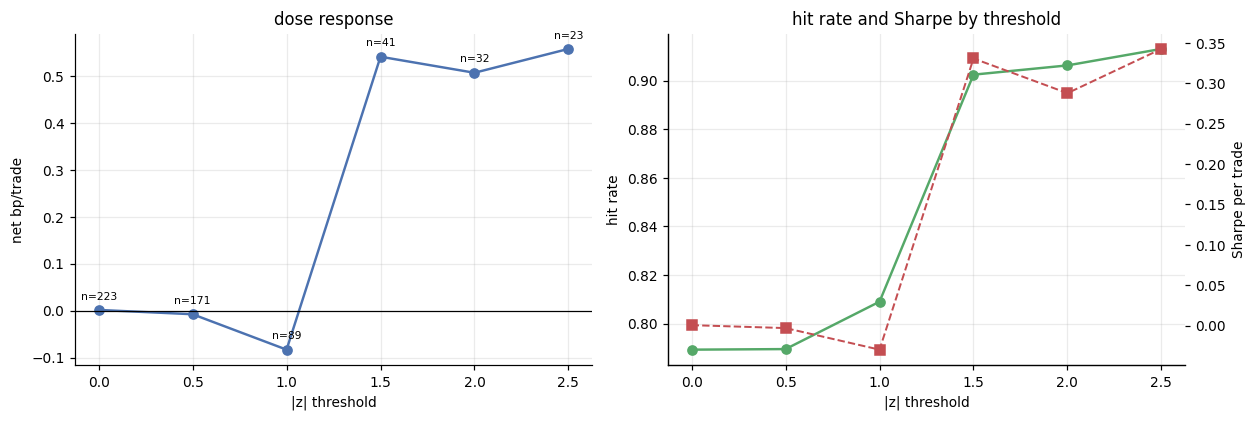

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.9))
ax[0].plot(dose["z_threshold"], dose["net_bp"], "o-", lw=1.6, color="#4c72b0")
ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_xlabel("|z| threshold"); ax[0].set_ylabel("net bp/trade")
ax[0].set_title("dose response")
for x_, y_, n_ in zip(dose["z_threshold"], dose["net_bp"], dose["trades"]):
    ax[0].annotate(f"n={n_}", (x_, y_), textcoords="offset points", xytext=(0, 7),
                   ha="center", fontsize=7)

ax[1].plot(dose["z_threshold"], dose["hit_rate"], "o-", lw=1.6, color="#55a868", label="hit rate")
ax[1].set_xlabel("|z| threshold"); ax[1].set_ylabel("hit rate")
ax2 = ax[1].twinx(); ax2.plot(dose["z_threshold"], dose["sr_per_trade"], "s--", lw=1.3,
                              color="#c44e52", label="Sharpe/trade")
ax2.set_ylabel("Sharpe per trade"); ax2.grid(False)
ax[1].set_title("hit rate and Sharpe by threshold")
plt.show()

## 7. The fork — fade, momentum, or fade-then-flip

The three directions on the same book.

**`momentum` is not the exact mirror of `fade` here, and it should not be.** Under a clock exit the two
are exact negatives — same two timestamps, opposite sign — and the raw-move notebooks use that as a
consistency check that sums to 0.000000. A *bracket* breaks the symmetry on purpose: a target and a
stop sit at different distances from entry, so the long and the short leave at different minutes and
at different prices. The residual below measures how much the bracket bends the symmetry, and a
non-zero value is the expected outcome rather than a bug.

`fade_then_flip` is the reprice branch of the hypothesis: fade first, and if stopped, reverse as a
second, separately-charged trade.

In [12]:
rows = {}
for direction in ("fade", "momentum", "fade_then_flip"):
    cfg = copy.deepcopy(CONFIG)
    cfg["signal"] = {**CONFIG["signal"], "direction": direction}
    bk = S.build_surprise_book(cfg, sur, raw)
    if bk.events.empty:
        continue
    if direction == "fade_then_flip":
        # a flip needs a stop to trigger it, so this variant is run with one
        r = X.ExitRule(name="flip", tp_bp=BRACKET["tp_bp"], sl_bp=1.0,
                       time_stop_min=BRACKET["time_stop_min"], mode="close")
        df = S.run_surprise_bracket(bk, r, cost_bp=COST_BP,
                                    flip_rule=X.ExitRule("flip|leg2", tp_bp=BRACKET["tp_bp"],
                                                         sl_bp=1.0, mode="close"))
    else:
        df = MX.run_bracket_fast(bk, RULE, cost_bp=COST_BP)
    if df.empty:
        continue
    rows[direction] = stats_of(df, direction)

dir_tbl = pd.DataFrame(rows.values()).set_index("label")
print(dir_tbl[["trades", "net_bp", "gross_bp", "hit_rate", "payoff", "sr_per_trade",
               "t_stat", "pct_target", "pct_stop", "pct_time"]].round(4).to_string())
print()
if "fade" in rows and "momentum" in rows:
    resid = rows["fade"]["gross_bp"] + rows["momentum"]["gross_bp"]
    print(f"fade {rows['fade']['gross_bp']:+.4f} gross vs momentum "
          f"{rows['momentum']['gross_bp']:+.4f}")
    print(f"residual {resid:+.6f} bp -- under a CLOCK exit this is exactly 0 because the two are")
    print("negatives of each other. Under a BRACKET it is not: the target and the stop sit at")
    print("different distances, so the two sides exit at different minutes. The residual is how")
    print("much asymmetry the bracket introduces, and it is small relative to the effect")
    print(f"({abs(resid) / abs(rows['fade']['gross_bp']) * 100:.1f}% of the fade's own gross).")

                trades  net_bp  gross_bp  hit_rate  payoff  sr_per_trade  t_stat  pct_target  pct_stop  pct_time
label                                                                                                           
fade                41  0.5408    0.7797    0.9024  0.2516        0.3305  2.1162      0.9024    0.0000    0.0976
momentum            41 -0.9751   -0.7362    0.6829  0.1896       -0.2824 -1.8085      0.6829    0.0000    0.3171
fade_then_flip      57  0.0395    0.2784    0.5965  0.7200        0.0296  0.2233      0.5965    0.4035    0.0000

fade +0.7797 gross vs momentum -0.7362
residual +0.043493 bp -- under a CLOCK exit this is exactly 0 because the two are
negatives of each other. Under a BRACKET it is not: the target and the stop sit at
different distances, so the two sides exit at different minutes. The residual is how
much asymmetry the bracket introduces, and it is small relative to the effect
(5.6% of the fade's own gross).


## 8. Sweeping the bracket

Target against stop, on the headline book. The tight end of the stop axis is the point: the reprice
branch of the hypothesis says a fade that goes wrong should be cut fast, so if that is true the tight
stops should be the good ones.

In [13]:
TARGETS = [1.0, 2.0, 3.0, 5.0]
STOPS   = [0.5, 1.0, 2.0, 3.0, 5.0, None]

rows, series = [], {}
t0 = time.time()
for tp, sl in itertools.product(TARGETS, STOPS):
    nm = f"tp{tp:g}|sl{'inf' if sl is None else format(sl, 'g')}"
    r = X.ExitRule(name=nm, tp_bp=tp, sl_bp=sl,
                   time_stop_min=BRACKET["time_stop_min"], mode="close")
    df = MX.run_bracket_fast(book, r, cost_bp=COST_BP)
    if df.empty:
        continue
    rows.append({**stats_of(df, nm), "tp": tp, "sl": np.nan if sl is None else sl})
    series[nm] = df.set_index("tag")["pnl_bp"]
sweep = pd.DataFrame(rows).set_index("label")
print(f"{len(sweep)} brackets in {time.time()-t0:.1f}s")
print(sweep.sort_values("net_bp", ascending=False)[
    ["trades", "net_bp", "hit_rate", "payoff", "sr_per_trade", "t_stat",
     "pct_target", "pct_stop", "pct_time"]].round(4).to_string())

24 brackets in 0.5s
           trades  net_bp  hit_rate  payoff  sr_per_trade  t_stat  pct_target  pct_stop  pct_time
label                                                                                            
tp1|slinf      41  0.5408    0.9024  0.2516        0.3305  2.1162      0.9024    0.0000    0.0976
tp5|sl1        41  0.3938    0.3415  2.7148        0.1412  0.9040      0.2195    0.6585    0.1220
tp2|slinf      41  0.3746    0.7073  0.5642        0.1365  0.8742      0.6585    0.0000    0.3415
tp1|sl5        41  0.3706    0.8780  0.2311        0.1916  1.2269      0.8780    0.0732    0.0488
tp5|slinf      41  0.3187    0.5854  0.8530        0.0750  0.4801      0.2439    0.0000    0.7561
tp5|sl0.5      41  0.3096    0.2683  3.8596        0.1293  0.8279      0.1707    0.7317    0.0976
tp5|sl5        41  0.2955    0.5610  0.9298        0.0745  0.4770      0.2439    0.2195    0.5366
tp5|sl2        41  0.2592    0.4878  1.2511        0.0786  0.5033      0.2195    0.4878    0.2927


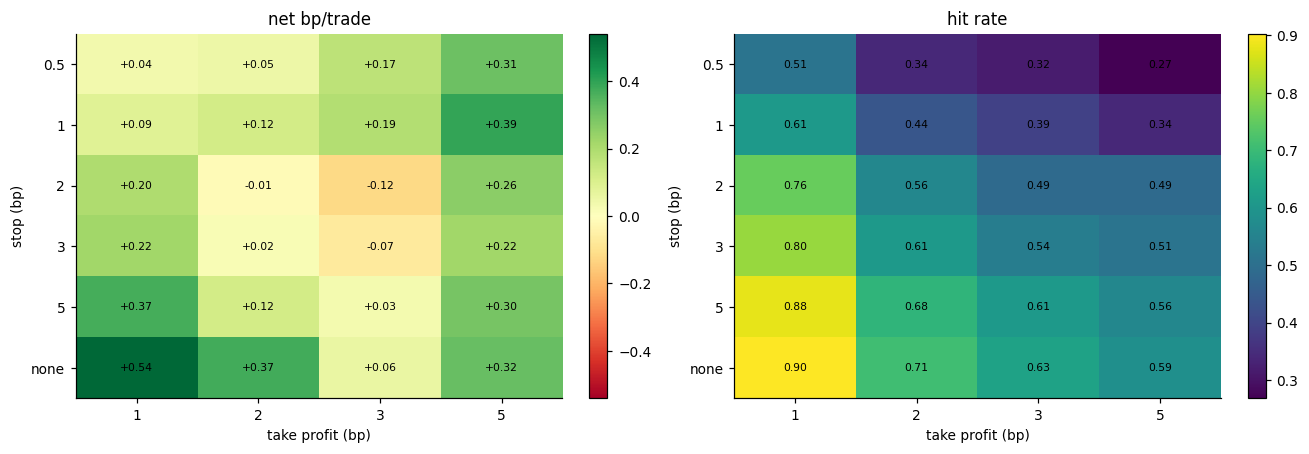

stop marginal -- median net bp/trade across targets
     cells  median_net  best_net  median_hit
sl                                          
0.5      4      0.1087    0.3096      0.3293
1.0      4      0.1540    0.3938      0.4146
2.0      4      0.0918    0.2592      0.5244
3.0      4      0.1206    0.2238      0.5732
5.0      4      0.2084    0.3706      0.6463
NaN      4      0.3467    0.5408      0.6707


In [14]:
piv_net = sweep.pivot_table(index="sl", columns="tp", values="net_bp", dropna=False)
piv_hit = sweep.pivot_table(index="sl", columns="tp", values="hit_rate", dropna=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, piv, title, cmap in ((axes[0], piv_net, "net bp/trade", "RdYlGn"),
                             (axes[1], piv_hit, "hit rate", "viridis")):
    M = piv.to_numpy(float)
    if title.startswith("net"):
        v = np.nanmax(np.abs(M)) or 1.0
        im = ax.imshow(M, cmap=cmap, vmin=-v, vmax=v, aspect="auto")
    else:
        im = ax.imshow(M, cmap=cmap, aspect="auto")
    ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels([f"{c:g}" for c in piv.columns])
    ax.set_yticks(range(piv.shape[0]))
    ax.set_yticklabels(["none" if np.isnan(i) else f"{i:g}" for i in piv.index])
    ax.set_xlabel("take profit (bp)"); ax.set_ylabel("stop (bp)")
    ax.set_title(title); ax.grid(False)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            if np.isfinite(M[i, j]):
                ax.text(j, i, f"{M[i, j]:+.2f}" if title.startswith("net") else f"{M[i, j]:.2f}",
                        ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

print("stop marginal -- median net bp/trade across targets")
print(sweep.groupby("sl", dropna=False).agg(cells=("net_bp", "size"),
                                            median_net=("net_bp", "median"),
                                            best_net=("net_bp", "max"),
                                            median_hit=("hit_rate", "median")).round(4).to_string())

## 9. The verdict — 40 matched placebo replicas

This is the section that decides. `surprise_replicas.py` runs the **identical 3,264-cell grid** on
books shifted by k business days, twenty shifts, in two variants:

- **`clean`** drops shifted minutes that collide with another real tier-1/2 release. Measured on this
  book, a −1 business-day shift of payrolls lands on Thursday jobless claims at the same 08:30, and
  59% of that replica's events sat on a real release minute. A control half made of other releases is
  not a no-news control.
- **`any-day`** keeps the collisions and asks the harder question: is *this* release special against
  whatever else was happening. It also turns out to be the better **matched** control — same cell
  count as the real grid, and the same share of thin cells.

Those runs take about 100 minutes, so this notebook **reads their committed output** rather than
recomputing it.

Three tests, in increasing order of how much they can be trusted — and the third one is in here
precisely because it must not be believed.

In [15]:
def _load(name):
    p = G.CACHE / f"surprise_replicas_{name}.csv"
    if not p.exists():
        return None
    d = pd.read_csv(p)
    return d[d["trades"] >= MIN_TRADES]

real_grid = _load("real")
reps = {v: _load(v) for v in ("clean", "any-day")}
reps = {k: v for k, v in reps.items() if v is not None}
assert real_grid is not None and reps, "run surprise_replicas.py first"

print(f"real grid : {len(real_grid):,} eligible cells, median {real_grid.trades.median():.0f} trades, "
      f"best net {real_grid.net_bp.max():+.4f}, best hit {real_grid.hit_rate.max():.4f}")
thin_real = float(real_grid.trades.between(30, 45).mean()) * 100
for v, d in reps.items():
    print(f"{v:8s}  : {d['shift'].nunique()} replicas, {len(d):,} cells, "
          f"median {d.trades.median():.0f} trades, "
          f"{float(d.trades.between(30, 45).mean())*100:.1f}% thin (real {thin_real:.1f}%)")

real grid : 3,264 eligible cells, median 82 trades, best net +0.8755, best hit 0.9062
clean     : 20 replicas, 39,006 cells, median 68 trades, 23.2% thin (real 41.0%)
any-day   : 20 replicas, 64,892 cells, median 85 trades, 42.5% thin (real 41.0%)


In [16]:
def exceed(obs, null):
    return (1 + int((np.asarray(null) >= obs).sum())) / (len(null) + 1)

print("=== 1. max against max -- honest for a grid search, and very noisy ===")
for v, d in reps.items():
    g = d.groupby("shift").agg(best_net=("net_bp", "max"), best_hit=("hit_rate", "max"))
    for col, obs in (("best_net", float(real_grid.net_bp.max())),
                     ("best_hit", float(real_grid.hit_rate.max()))):
        null = g[col].to_numpy()
        print(f"  [{v:7s}] {col:9s} real {obs:+.4f}  replicas {null.min():+.4f}..{null.max():+.4f} "
              f"(med {np.median(null):+.4f})  {int((null >= obs).sum())}/{len(null)} beat  "
              f"p={exceed(obs, null):.4f}")

=== 1. max against max -- honest for a grid search, and very noisy ===
  [clean  ] best_net  real +0.8755  replicas +0.1715..+0.9718 (med +0.5454)  2/20 beat  p=0.1429
  [clean  ] best_hit  real +0.9062  replicas +0.7333..+0.8974 (med +0.7753)  0/20 beat  p=0.0476
  [any-day] best_net  real +0.8755  replicas +0.2468..+1.3965 (med +0.6013)  4/20 beat  p=0.2381
  [any-day] best_hit  real +0.9062  replicas +0.7436..+0.8718 (med +0.7861)  0/20 beat  p=0.0476


In [17]:
print("=== 2. RATE of high-hit cells -- the test the conclusion rests on ===")
print("    (a property of the whole grid, so no cell is selected and selection is charged to nobody)")
out = []
for v, d in reps.items():
    for label, (r_, p_) in {"all": (real_grid, d),
                            "thin 30-45": (real_grid[real_grid.trades.between(30, 45)],
                                           d[d.trades.between(30, 45)])}.items():
        for t in (0.80, 0.85, 0.87):
            obs = float((r_.hit_rate >= t).mean()) * 1000
            tot = p_.groupby("shift").size()
            per = p_[p_.hit_rate >= t].groupby("shift").size().reindex(tot.index, fill_value=0)
            null = (per / tot * 1000).to_numpy()
            out.append({"variant": v, "band": label, "hit>=": t,
                        "real /1000": round(obs, 2), "replica med": round(float(np.median(null)), 2),
                        "replica max": round(float(null.max()), 2),
                        "beat": f"{int((null >= obs).sum())}/{len(null)}",
                        "p": round(exceed(obs, null), 4)})
print(pd.DataFrame(out).to_string(index=False))

=== 2. RATE of high-hit cells -- the test the conclusion rests on ===
    (a property of the whole grid, so no cell is selected and selection is charged to nobody)
variant       band  hit>=  real /1000  replica med  replica max beat      p
  clean        all   0.80       17.16          0.0        19.49 1/20 0.0952
  clean        all   0.85        3.98          0.0         6.09 1/20 0.0952
  clean        all   0.87        2.76          0.0         2.44 0/20 0.0476
  clean thin 30-45   0.80       36.59          0.0        45.52 1/20 0.0952
  clean thin 30-45   0.85        9.71          0.0        14.22 1/20 0.0952
  clean thin 30-45   0.87        6.72          0.0         5.69 0/20 0.0476
any-day        all   0.80       17.16          0.0         9.19 0/20 0.0476
any-day        all   0.85        3.98          0.0         1.23 0/20 0.0476
any-day        all   0.87        2.76          0.0         0.61 0/20 0.0476
any-day thin 30-45   0.80       36.59          0.0        17.79 0/20 0.0476


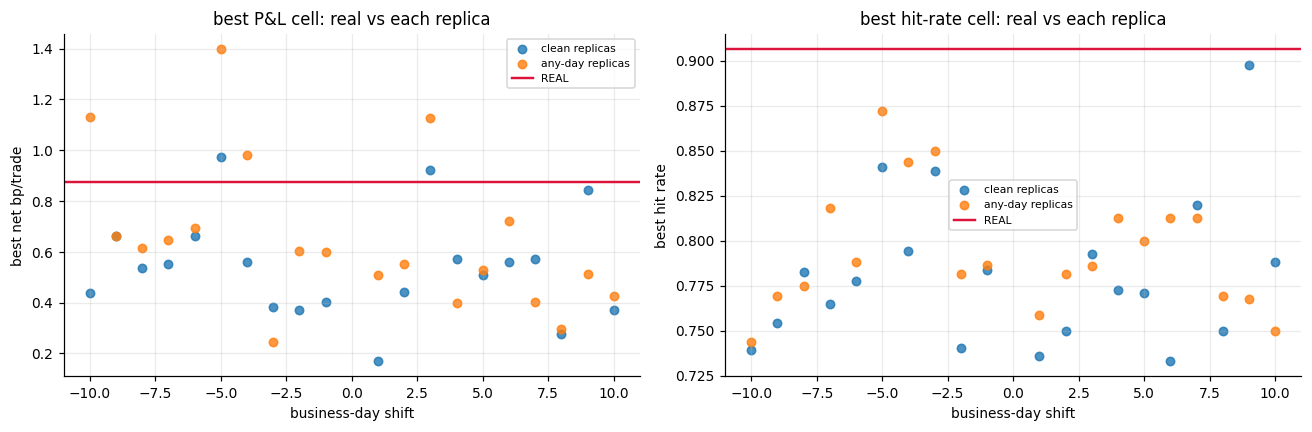

The P&L panel has replicas ABOVE the real line; the hit-rate panel does not.
That difference, not either panel alone, is the result.


In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, (v, d) in enumerate(reps.items()):
    g = d.groupby("shift").agg(best_net=("net_bp", "max"), best_hit=("hit_rate", "max"))
    ax[0].scatter(g.index, g["best_net"], s=30, label=f"{v} replicas", alpha=0.8)
    ax[1].scatter(g.index, g["best_hit"], s=30, label=f"{v} replicas", alpha=0.8)
ax[0].axhline(real_grid.net_bp.max(), color="crimson", lw=1.6, label="REAL")
ax[0].set_xlabel("business-day shift"); ax[0].set_ylabel("best net bp/trade")
ax[0].set_title("best P&L cell: real vs each replica"); ax[0].legend(fontsize=7)
ax[1].axhline(real_grid.hit_rate.max(), color="crimson", lw=1.6, label="REAL")
ax[1].set_xlabel("business-day shift"); ax[1].set_ylabel("best hit rate")
ax[1].set_title("best hit-rate cell: real vs each replica"); ax[1].legend(fontsize=7)
plt.show()

print("The P&L panel has replicas ABOVE the real line; the hit-rate panel does not.")
print("That difference, not either panel alone, is the result.")

In [19]:
print("=== 3. the winning cell against its own twins -- BIASED, illustration only ===")
print()
print("This fixes the winning configuration and scores the placebos at that SAME configuration.")
print("It returns the most impressive numbers in the study and it is not evidence: the config was")
print("chosen BECAUSE it was the real grid's maximum, and the placebos never got to pick their own,")
print("so selection is charged to one side only. It is shown so that nobody rediscovers it and")
print("quotes it as though it were clean.")
print()
best_cfgs = real_grid.sort_values("hit_rate", ascending=False).head(2)["config"].tolist()
for cfg_nm in best_cfgs:
    rv = real_grid[real_grid.config == cfg_nm]
    for v, d in reps.items():
        tw = d[d.config == cfg_nm]
        if not len(tw) or not len(rv):
            continue
        for col in ("hit_rate", "net_bp"):
            obs, null = float(rv[col].iloc[0]), tw[col].to_numpy()
            print(f"  [{v:7s}] {cfg_nm}  {col:9s} real {obs:+.4f} vs twin median "
                  f"{np.median(null):+.4f}  {int((null >= obs).sum())}/{len(null)} beat  "
                  f"p={exceed(obs, null):.4f}   <-- BIASED")

=== 3. the winning cell against its own twins -- BIASED, illustration only ===

This fixes the winning configuration and scores the placebos at that SAME configuration.
It returns the most impressive numbers in the study and it is not evidence: the config was
chosen BECAUSE it was the real grid's maximum, and the placebos never got to pick their own,
so selection is charged to one side only. It is shown so that nobody rediscovers it and
quotes it as though it were clean.

  [any-day] fade|e2|z2|tp1|slinf|t240  hit_rate  real +0.9062 vs twin median +0.6774  0/19 beat  p=0.0500   <-- BIASED
  [any-day] fade|e2|z2|tp1|slinf|t240  net_bp    real +0.5066 vs twin median -0.2255  0/19 beat  p=0.0500   <-- BIASED
  [clean  ] fade|e2|z1.5|tp1|slinf|t240  hit_rate  real +0.9024 vs twin median +0.6424  0/4 beat  p=0.2000   <-- BIASED
  [clean  ] fade|e2|z1.5|tp1|slinf|t240  net_bp    real +0.5408 vs twin median -0.3192  0/4 beat  p=0.2000   <-- BIASED
  [any-day] fade|e2|z1.5|tp1|slinf|t240  hit_

## 10. What the search cost, and where it sits in the whole study

In [20]:
Xm = pd.DataFrame(series).sort_index()
obs = np.array([Xm[c].dropna().mean() / Xm[c].dropna().std(ddof=1)
                if Xm[c].notna().sum() > 1 else 0.0 for c in Xm.columns])
null = shared_sign_flip_null(Xm, draws=2000, rng=np.random.default_rng(20260811))
p_best = selection_bias_pvalue(obs, null)
rw = romano_wolf(obs, null, alpha=0.05, names=list(Xm.columns))
ras = ras_bound(Xm.fillna(0.0), delta=0.05, draws=2000,
                rng=np.random.default_rng(7), names=list(Xm.columns))
print(f"family matrix: {Xm.shape[1]:,} brackets x {Xm.shape[0]:,} trades")
print(f"selection-bias adjusted p for the BEST cell : {p_best:.4f}")
print(f"Romano-Wolf rejects at 5% FWER              : {rw.n_rejected:,} of {rw.n_strategies:,}")
print(f"Rademacher positive                         : {int((ras.bound > 0).sum()):,} of {ras.N:,}")

family matrix: 24 brackets x 41 trades
selection-bias adjusted p for the BEST cell : 0.1444
Romano-Wolf rejects at 5% FWER              : 0 of 24
Rademacher positive                         : 0 of 24


In [21]:
p = G.CACHE / "best_sharpe_league.csv"
if p.exists():
    lg = pd.read_csv(p)
    print(f"{len(lg):,} cells across every search in this study, all net of one round-trip tick")
    print()
    print(lg.groupby("search").agg(cells=("ann_sharpe", "size"),
                                   median_ann=("ann_sharpe", "median"),
                                   best_ann=("ann_sharpe", "max"),
                                   pct_net_positive=("net_bp", lambda s: float((s > 0).mean()))
                                   ).round(4).to_string())
    print("\n=== top 12 by annualised Sharpe, anywhere in the study ===")
    print(lg.sort_values("ann_sharpe", ascending=False).head(12)[
        ["search", "config", "trades", "trades_per_year", "net_bp", "hit_rate",
         "sr_per_trade", "ann_sharpe"]].round(4).to_string(index=False))
    print(f"\ncells clearing annualised Sharpe 0.5: {int((lg.ann_sharpe > 0.5).sum())}"
          f"   1.0: {int((lg.ann_sharpe > 1.0).sum())}   of {len(lg):,}")
else:
    print("best_sharpe_league.csv not present -- run best_sharpe_league.py")

12,302 cells across every search in this study, all net of one round-trip tick

                    cells  median_ann  best_ann  pct_net_positive
search                                                           
CPI x TY brackets    4920     -0.2192    0.6238            0.2443
consensus surprise   3264     -0.3675    0.7680            0.2316
grid search          1846     -0.9609    0.3490            0.0271
parameter search     2272     -0.8326    0.6699            0.0625

=== top 12 by annualised Sharpe, anywhere in the study ===
            search                                config  trades  trades_per_year  net_bp  hit_rate  sr_per_trade  ann_sharpe
consensus surprise           fade|e2|z1.5|tp1|slinf|t240      41           5.4004  0.5408    0.9024        0.3305      0.7680
consensus surprise  fade_then_flip|e15|z1.5|tp2|sl1|t120      60           7.9030  0.4506    0.5500        0.2624      0.7376
consensus surprise  fade_then_flip|e15|z1.5|tp2|sl1|t240      60           7.9030  0.4

## 11. Verdict

The result splits by statistic, and the split *is* the finding.

**Hit-rate enrichment is real.** The real grid produces high-hit cells at a rate no replica matches,
in both controls, at every threshold, and it survives conditioning on the thin trade band where a high
hit rate is cheapest. It is a rate over the whole grid rather than a selected cell, so nothing about
it is a search artifact.

**The P&L maximum is not.** Replicas routinely beat it. A maximum over 3,264 cells is an extreme order
statistic, and this one sits inside the range that placebo days produce.

So what a large consensus surprise buys is **the reliability of a small fade, not the size of the
payoff**. Every high-hit cell in the study is a 1 bp target, always a fade and never momentum, always
`|z| >= 1.5`. And 1 bp against a 0.239 bp round-trip tick is a thin business: the reliability is real,
the profit is marginal, and those two sentences are not in tension.

On the fork in the hypothesis: **the reprice branch does not pay**. Tight stops have the worst median
in every direction, and while adding the flip lifts the best cell it lowers the typical one — a fat
right tail rather than a better strategy.